## Appearance-Based Model (Option B) — Appearance + dimensionality reduction

Pipeline: **multi-scale HOG + HSV histogram + LBP → standardize (train-only) → PCA (GPU via `torch.pca_lowrank` when available) → SVC (RBF kernel)** over PCA settings.

Internal metrics use a stratified 80/20 split; the best configuration is **retrained on all labeled images** before Kaggle submission. Test-time **horizontal flip** averaging is optional (`USE_TEST_TIME_FLIP` in the submission cell).

- **Color images** letterboxed to `IMG_SIZE_OPT_B` (no stretch) for consistent global appearance.
- **Triple-scale HOG** on luminance: `ppc=(8,8)`, `(12,12)`, `(16,16)`, 9 orientations, `cpb=(2,2)`.
- **HSV**: 16 bins per channel; **LBP**: uniform pattern histogram (24 points, radius 3).
- **PCA**: fixed component counts **or** retained variance (0.95 / 0.99), with optional cap `PCA_VAR_Q_CAP` for GPU SVD size.


In [1]:
from pathlib import Path
import sys

import torch

# Add repository root so src imports work when running from notebooks/.
project_root = Path().resolve().parent
sys.path.append(str(project_root))

from src.config import (
    PART1_KAGGLE_DIR,
    PART2_IMAGES_DIR,
    PART2_ANNOTATIONS_DIR,
    validate_data_layout,
)

validate_data_layout()

# Option B: PyTorch PCA on GPU when CUDA works (classifiers fit on CPU)
CUDA_DEVICE_INDEX_B = 0
_has_cuda = torch.cuda.is_available()
if _has_cuda:
    torch.cuda.set_device(CUDA_DEVICE_INDEX_B)
    device_b = torch.device("cuda", CUDA_DEVICE_INDEX_B)
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.set_float32_matmul_precision("high")
    try:
        _ = torch.zeros(2, 2, device=device_b, dtype=torch.float32).mean()
        torch.cuda.synchronize()
        _cw = torch.nn.Conv2d(3, 8, kernel_size=3, padding=1).to(device_b)
        _ = _cw(torch.zeros(1, 3, 16, 16, device=device_b))
        torch.cuda.synchronize()
    except RuntimeError:
        device_b = torch.device("cpu")
elif getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
    device_b = torch.device("mps")
else:
    device_b = torch.device("cpu")

_TORCH_PCA_USE_GPU = device_b.type in ("cuda", "mps")

print("Data paths validated:")
print(f"- Part 1: {PART1_KAGGLE_DIR}")
print(f"- Part 2 Images: {PART2_IMAGES_DIR}")
print(f"- Part 2 Annotations: {PART2_ANNOTATIONS_DIR}")
print(f"torch {torch.__version__} | Option B PCA device: {device_b}", end="")
if device_b.type == "cuda":
    print(f" | {torch.cuda.get_device_name(torch.cuda.current_device())}")
else:
    print()
if _has_cuda and device_b.type != "cuda":
    print(
        "Note: PyTorch could not run CUDA kernels on this GPU "
        "(wheel/arch mismatch). PCA falls back to CPU."
    )

Data paths validated:
- Part 1: C:\Users\cotte\Documents\Program\github\ecse415-final-project\data\part1\data\kaggle
- Part 2 Images: C:\Users\cotte\Documents\Program\github\ecse415-final-project\data\part2\Stanford Dog Dataset\Images
- Part 2 Annotations: C:\Users\cotte\Documents\Program\github\ecse415-final-project\data\part2\Stanford Dog Dataset\Annotation
torch 2.11.0+cu128 | Option B PCA device: cuda:0 | NVIDIA GeForce RTX 5070 Ti


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn.base import clone
from sklearn.decomposition import PCA
from sklearn.svm import SVC

from src.config import OUTPUTS_DIR
from src.utils import (
    generate_submission_csv,
    load_labeled_images,
    load_labeled_images_memmap,
    load_test_images,
    split_data,
    standardize_features,
)
from src.evaluation import compute_metrics, compute_confusion_matrix, compare_models
from src.visualization import (
    plot_confusion_matrix,
    plot_sample_predictions,
    plot_model_comparison,
)


# ---------------------------------------------------------------------------
# PCA on GPU (torch) when `device_b` is cuda/mps; sklearn CPU fallback
# ---------------------------------------------------------------------------


def _fit_pca_torch_train_test(X_train, X_test, n_components, dev):
    X_train = np.ascontiguousarray(X_train, dtype=np.float32)
    X_test = np.ascontiguousarray(X_test, dtype=np.float32)
    n_samples = X_train.shape[0]
    total_var = np.var(X_train, axis=0, ddof=1).sum()

    Xt = torch.from_numpy(X_train).to(dev)
    Xte = torch.from_numpy(X_test).to(dev)
    mean = Xt.mean(dim=0, keepdim=True)
    Xt_c = Xt - mean
    Xte_c = Xte - mean
    q = min(n_components, Xt_c.shape[0] - 1, Xt_c.shape[1])
    q = max(1, q)
    _U, S, V = torch.pca_lowrank(Xt_c, q=q, center=False)
    Zt = Xt_c @ V
    Zte = Xte_c @ V
    s_cpu = S.detach().cpu().numpy()
    ev = (s_cpu ** 2) / (n_samples - 1)
    evr = ev / total_var if total_var > 1e-12 else np.ones(q) / q

    class TorchPcaFacade:
        def __init__(self):
            self.mean_ = mean.cpu().numpy().astype(np.float64)
            self.components_ = V.T.cpu().numpy()
            self.explained_variance_ratio_ = evr.astype(np.float64)
            self._V = V.detach().cpu().numpy().astype(np.float32)
            self._mean_1d = self.mean_.reshape(-1)

        def transform(self, X):
            X = np.ascontiguousarray(X, dtype=np.float32)
            Xm = X - self._mean_1d
            return (Xm @ self._V).astype(np.float32)

    fac = TorchPcaFacade()
    return (
        Zt.detach().cpu().numpy().astype(np.float32),
        Zte.detach().cpu().numpy().astype(np.float32),
        fac,
    )


def _fit_pca_torch_train_only(X, n_components, dev):
    X = np.ascontiguousarray(X, dtype=np.float32)
    n_samples = X.shape[0]
    total_var = np.var(X, axis=0, ddof=1).sum()
    Xt = torch.from_numpy(X).to(dev)
    mean = Xt.mean(dim=0, keepdim=True)
    Xt_c = Xt - mean
    q = min(n_components, Xt_c.shape[0] - 1, Xt_c.shape[1])
    q = max(1, q)
    _U, S, V = torch.pca_lowrank(Xt_c, q=q, center=False)
    Z = Xt_c @ V
    s_cpu = S.detach().cpu().numpy()
    ev = (s_cpu ** 2) / (n_samples - 1)
    evr = ev / total_var if total_var > 1e-12 else np.ones(q) / q

    class TorchPcaFacadeFull:
        def __init__(self):
            self.mean_ = mean.cpu().numpy().astype(np.float64)
            self.components_ = V.T.cpu().numpy()
            self.explained_variance_ratio_ = evr.astype(np.float64)
            self._V = V.detach().cpu().numpy().astype(np.float32)
            self._mean_1d = self.mean_.reshape(-1)

        def transform(self, X):
            X = np.ascontiguousarray(X, dtype=np.float32)
            Xm = X - self._mean_1d
            return (Xm @ self._V).astype(np.float32)

    return Z.detach().cpu().numpy().astype(np.float32), TorchPcaFacadeFull()


PCA_VAR_Q_CAP = 2048


def _fit_pca_torch_train_test_variance(
    X_train, X_test, variance_ratio, dev, q_cap=PCA_VAR_Q_CAP
):
    X_train = np.ascontiguousarray(X_train, dtype=np.float32)
    X_test = np.ascontiguousarray(X_test, dtype=np.float32)
    n_samples = X_train.shape[0]
    total_var = np.var(X_train, axis=0, ddof=1).sum()

    Xt = torch.from_numpy(X_train).to(dev)
    Xte = torch.from_numpy(X_test).to(dev)
    mean = Xt.mean(dim=0, keepdim=True)
    Xt_c = Xt - mean
    Xte_c = Xte - mean
    q = min(q_cap, Xt_c.shape[0] - 1, Xt_c.shape[1])
    q = max(1, q)
    _U, S, V = torch.pca_lowrank(Xt_c, q=q, center=False)
    s_cpu = S.detach().cpu().numpy()
    ev = (s_cpu ** 2) / (n_samples - 1)
    evr = ev / total_var if total_var > 1e-12 else np.ones(q) / q

    cum = np.cumsum(evr)
    k = len(cum)
    for j in range(len(cum)):
        if cum[j] >= variance_ratio:
            k = j + 1
            break

    V = V[:, :k]
    Zt = Xt_c @ V
    Zte = Xte_c @ V
    evr_k = evr[:k]

    class TorchPcaFacadeVar:
        def __init__(self):
            self.mean_ = mean.cpu().numpy().astype(np.float64)
            self.components_ = V.T.cpu().numpy()
            self.explained_variance_ratio_ = evr_k.astype(np.float64)
            self._V = V.detach().cpu().numpy().astype(np.float32)
            self._mean_1d = self.mean_.reshape(-1)

        def transform(self, X):
            X = np.ascontiguousarray(X, dtype=np.float32)
            Xm = X - self._mean_1d
            return (Xm @ self._V).astype(np.float32)

    fac = TorchPcaFacadeVar()
    return (
        Zt.detach().cpu().numpy().astype(np.float32),
        Zte.detach().cpu().numpy().astype(np.float32),
        fac,
    )


def _fit_pca_torch_train_only_variance(
    X, variance_ratio, dev, q_cap=PCA_VAR_Q_CAP
):
    X = np.ascontiguousarray(X, dtype=np.float32)
    n_samples = X.shape[0]
    total_var = np.var(X, axis=0, ddof=1).sum()
    Xt = torch.from_numpy(X).to(dev)
    mean = Xt.mean(dim=0, keepdim=True)
    Xt_c = Xt - mean
    q = min(q_cap, Xt_c.shape[0] - 1, Xt_c.shape[1])
    q = max(1, q)
    _U, S, V = torch.pca_lowrank(Xt_c, q=q, center=False)
    s_cpu = S.detach().cpu().numpy()
    ev = (s_cpu ** 2) / (n_samples - 1)
    evr = ev / total_var if total_var > 1e-12 else np.ones(q) / q

    cum = np.cumsum(evr)
    k = len(cum)
    for j in range(len(cum)):
        if cum[j] >= variance_ratio:
            k = j + 1
            break

    V = V[:, :k]
    Z = Xt_c @ V
    evr_k = evr[:k]

    class TorchPcaFacadeVarFull:
        def __init__(self):
            self.mean_ = mean.cpu().numpy().astype(np.float64)
            self.components_ = V.T.cpu().numpy()
            self.explained_variance_ratio_ = evr_k.astype(np.float64)
            self._V = V.detach().cpu().numpy().astype(np.float32)
            self._mean_1d = self.mean_.reshape(-1)

        def transform(self, X):
            X = np.ascontiguousarray(X, dtype=np.float32)
            Xm = X - self._mean_1d
            return (Xm @ self._V).astype(np.float32)

    return Z.detach().cpu().numpy().astype(np.float32), TorchPcaFacadeVarFull()


def apply_pca_features_auto(X_train, X_test, pca_spec):
    if isinstance(pca_spec, tuple) and pca_spec[0] == "var":
        variance_ratio = pca_spec[1]
        if _TORCH_PCA_USE_GPU:
            try:
                return _fit_pca_torch_train_test_variance(
                    X_train, X_test, variance_ratio, device_b
                )
            except Exception:
                pass
        pca = PCA(n_components=variance_ratio, random_state=42)
        X_tr = pca.fit_transform(X_train)
        X_te = pca.transform(X_test)
        return X_tr, X_te, pca

    n_components = int(pca_spec)
    if _TORCH_PCA_USE_GPU:
        try:
            return _fit_pca_torch_train_test(X_train, X_test, n_components, device_b)
        except Exception:
            pass
    pca = PCA(n_components=n_components, random_state=42)
    X_tr = pca.fit_transform(X_train)
    X_te = pca.transform(X_test)
    return X_tr, X_te, pca


def fit_pca_train_only_auto(X, pca_spec):
    if isinstance(pca_spec, tuple) and pca_spec[0] == "var":
        variance_ratio = pca_spec[1]
        if _TORCH_PCA_USE_GPU:
            try:
                return _fit_pca_torch_train_only_variance(X, variance_ratio, device_b)
            except Exception:
                pass
        pca = PCA(n_components=variance_ratio, random_state=42)
        Z = pca.fit_transform(X)
        return Z, pca

    n_components = int(pca_spec)
    if _TORCH_PCA_USE_GPU:
        try:
            return _fit_pca_torch_train_only(X, n_components, device_b)
        except Exception:
            pass
    pca = PCA(n_components=n_components, random_state=42)
    Z = pca.fit_transform(X)
    return Z, pca


def format_pca_spec_label(pca_spec):
    if isinstance(pca_spec, tuple) and pca_spec[0] == "var":
        return "var{:.2f}".format(pca_spec[1])
    return str(int(pca_spec))


In [3]:
# Load COLOR images (needed for HSV features)
# Larger resize improves global appearance detail for HOG; (128, 128) is faster if you need quick iteration.
IMG_SIZE_OPT_B = (96, 96)

# Preserve aspect ratio; pad to IMG_SIZE_OPT_B with black (matches load_test_images below).
LETTERBOX = True

# Disk-backed float32 memmap (lower RAM than loading all images into a dense ndarray).
# First run writes outputs/cache/part1_labeled_memmap/; set rebuild=True to refresh after data changes.
USE_LABELED_MEMMAP_CACHE = True
MEMMAP_CACHE_DIR = OUTPUTS_DIR / "cache" / "part1_labeled_memmap"

if USE_LABELED_MEMMAP_CACHE:
    X, y, train_ids = load_labeled_images_memmap(
        img_size=IMG_SIZE_OPT_B,
        grayscale=False,
        return_ids=True,
        cache_dir=MEMMAP_CACHE_DIR,
        rebuild=False,
        letterbox=LETTERBOX,
    )
else:
    X, y, train_ids = load_labeled_images(
        img_size=IMG_SIZE_OPT_B,
        grayscale=False,
        return_ids=True,
        letterbox=LETTERBOX,
    )

print(f"Loaded images shape: {X.shape}")
print(f"Loaded labels shape: {y.shape}")
print(f"Example IDs: {train_ids[:3]}")
print(f"Class distribution: {np.bincount(y)}  (cat, dog)")

Loaded images shape: (20000, 96, 96, 3)
Loaded labels shape: (20000,)
Example IDs: ['cat.0' 'cat.1' 'cat.10']
Class distribution: [10021  9979]  (cat, dog)


In [4]:
# Split labeled data into train and internal test sets (stratified 80/20)
X_train, X_test, y_train, y_test = split_data(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

print(f"Train set: {X_train.shape}, {y_train.shape}")
print(f"Test set:  {X_test.shape}, {y_test.shape}")

Train set: (16000, 96, 96, 3), (16000,)
Test set:  (4000, 96, 96, 3), (4000,)


In [5]:
# ---------------------------------------------------------------------------
# Feature extraction (multi-scale HOG + HSV + optional LBP) — parallel CPU workers in src.utils
# ---------------------------------------------------------------------------

from src.utils import extract_multiscale_hog_hsv_features as extract_combined_features

# skimage HOG is CPU-only; use all cores (set to 1 for a single-process tqdm bar)
FEAT_EXTRACT_N_JOBS = -1

print("Feature extraction helpers defined.")
print(
    "Pipeline: triple-scale HOG (ppc=8,12,16) + HSV histogram (16 bins/channel) + LBP histogram"
)


Feature extraction helpers defined.
Pipeline: triple-scale HOG (ppc=8,12,16) + HSV histogram (16 bins/channel) + LBP histogram


In [6]:
# ---------------------------------------------------------------------------
# Extract global appearance features: multi-scale HOG + HSV + LBP, then standardize (train-only)
# ---------------------------------------------------------------------------

HOG_ORIENTATIONS = 9
HOG_CELLS_PER_BLOCK = (2, 2)
HOG_SCALES_PPC = [(8, 8), (12, 12), (16, 16)]
HSV_BINS = 16
INCLUDE_LBP = True
LBP_N_POINTS = 24
LBP_RADIUS = 3

print("Extracting features for train split...")
X_train_feats = extract_combined_features(
    X_train,
    hog_orientations=HOG_ORIENTATIONS,
    hog_cells_per_block=HOG_CELLS_PER_BLOCK,
    hog_scales_ppc=HOG_SCALES_PPC,
    hsv_bins=HSV_BINS,
    n_jobs=FEAT_EXTRACT_N_JOBS,
    include_lbp=INCLUDE_LBP,
    lbp_n_points=LBP_N_POINTS,
    lbp_radius=LBP_RADIUS,
)

print("Extracting features for test split...")
X_test_feats = extract_combined_features(
    X_test,
    hog_orientations=HOG_ORIENTATIONS,
    hog_cells_per_block=HOG_CELLS_PER_BLOCK,
    hog_scales_ppc=HOG_SCALES_PPC,
    hsv_bins=HSV_BINS,
    n_jobs=FEAT_EXTRACT_N_JOBS,
    include_lbp=INCLUDE_LBP,
    lbp_n_points=LBP_N_POINTS,
    lbp_radius=LBP_RADIUS,
)

n_feat = X_train_feats.shape[1]
n_hsv = 3 * HSV_BINS
n_lbp = LBP_N_POINTS + 2
print("")
print("Raw feature dimensionality: {}".format(n_feat))
print(
    "  (triple-scale HOG + {} HSV + {} LBP features)".format(n_hsv, n_lbp)
)

X_train_s, X_test_s, feat_scaler = standardize_features(X_train_feats, X_test_feats)
print("Features standardized.")


Extracting features for train split...
Extracting features for test split...

Raw feature dimensionality: 7094
  (triple-scale HOG + 48 HSV + 26 LBP features)
Features standardized.


In [7]:
# ---------------------------------------------------------------------------
# Sweep: PCA (fixed n or retained variance on GPU) x SVC RBF
# ---------------------------------------------------------------------------

pca_specs = []
for n in [200, 300, 400, 500]:
    pca_specs.append(n)
for vr in [0.95, 0.99]:
    pca_specs.append(("var", vr))

classifier_specs = [
    (
        "SVC-RBF",
        SVC(
            kernel="rbf",
            C=10.0,
            gamma="scale",
            class_weight="balanced",
            random_state=42,
        ),
    ),
]

results = {}

best_accuracy = -1.0
best_pca_spec = None
best_pca = None
best_clf = None
best_clf_label = None
best_y_pred = None

for pca_spec in pca_specs:
    X_tr_pca, X_te_pca, pca = apply_pca_features_auto(
        X_train_s,
        X_test_s,
        pca_spec,
    )

    for clf_label, clf_template in classifier_specs:
        clf = clone(clf_template)
        clf.fit(X_tr_pca, y_train)
        y_pred = clf.predict(X_te_pca)
        metrics = compute_metrics(y_test, y_pred)
        pca_tag = format_pca_spec_label(pca_spec)
        name = "HOG+HSV+LBP+PCA-{}+{}".format(pca_tag, clf_label)
        results[name] = metrics
        print("{} -> {}".format(name, metrics))

        acc = metrics["accuracy"]
        if acc > best_accuracy:
            best_accuracy = acc
            best_pca_spec = pca_spec
            best_pca = pca
            best_clf = clf
            best_clf_label = clf_label
            best_y_pred = y_pred

print("")
print(
    "Best Option B: PCA spec={!r}, clf={}, accuracy={:.4f}".format(
        best_pca_spec,
        best_clf_label,
        best_accuracy,
    )
)


HOG+HSV+LBP+PCA-200+SVC-RBF -> {'accuracy': 0.81275, 'precision': 0.8137896326119779, 'recall': 0.8101202404809619, 'f1': 0.81195079086116}
HOG+HSV+LBP+PCA-300+SVC-RBF -> {'accuracy': 0.812, 'precision': 0.8106893106893107, 'recall': 0.81312625250501, 'f1': 0.8119059529764883}
HOG+HSV+LBP+PCA-400+SVC-RBF -> {'accuracy': 0.815, 'precision': 0.8171717171717172, 'recall': 0.8106212424849699, 'f1': 0.8138832997987927}
HOG+HSV+LBP+PCA-500+SVC-RBF -> {'accuracy': 0.8155, 'precision': 0.8179979777553084, 'recall': 0.8106212424849699, 'f1': 0.8142929038751887}
HOG+HSV+LBP+PCA-var0.95+SVC-RBF -> {'accuracy': 0.818, 'precision': 0.8231396534148828, 'recall': 0.8091182364729459, 'f1': 0.8160687215765539}
HOG+HSV+LBP+PCA-var0.99+SVC-RBF -> {'accuracy': 0.81925, 'precision': 0.8242485990830362, 'recall': 0.8106212424849699, 'f1': 0.8173781257893408}

Best Option B: PCA spec=('var', 0.99), clf=SVC-RBF, accuracy=0.8193


In [8]:
# Compare all configurations in a metrics table
comparison_df = compare_models(results)
comparison_df

,accuracy,precision,recall,f1
model,,,,
HOG+HSV+LBP+PCA-var0.99+SVC-RBF,0.81925,0.824249,0.810621,0.817378
HOG+HSV+LBP+PCA-var0.95+SVC-RBF,0.81800,0.823140,0.809118,0.816069
HOG+HSV+LBP+PCA-500+SVC-RBF,0.81550,0.817998,0.810621,0.814293
HOG+HSV+LBP+PCA-400+SVC-RBF,0.81500,0.817172,0.810621,0.813883
HOG+HSV+LBP+PCA-200+SVC-RBF,0.81275,0.813790,0.810120,0.811951
HOG+HSV+LBP+PCA-300+SVC-RBF,0.81200,0.810689,0.813126,0.811906


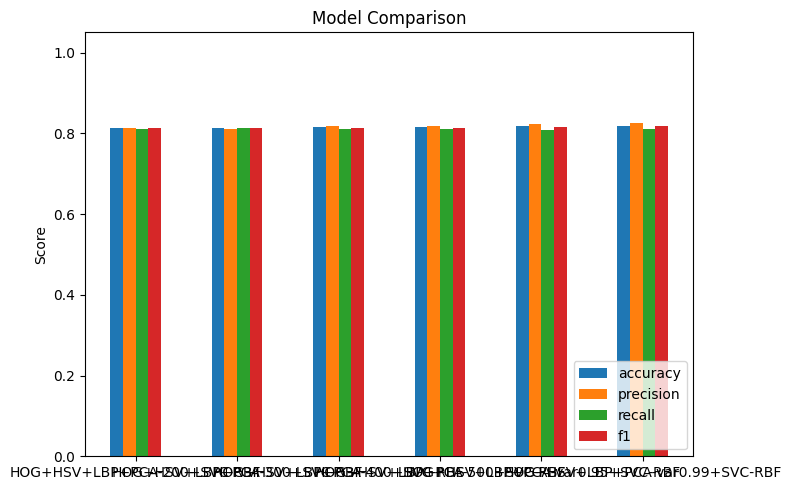

In [9]:
# Plot grouped metric comparison across all configurations
plot_model_comparison(results)

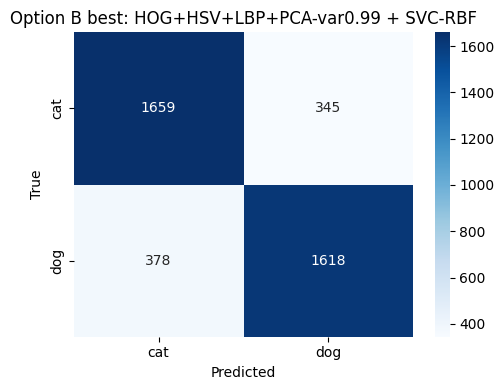

In [10]:
# Compute and display confusion matrix for the best model
best_cm = compute_confusion_matrix(y_test, best_y_pred)
_pca_t = format_pca_spec_label(best_pca_spec)
plot_confusion_matrix(
    best_cm,
    title=(
        "Option B best: HOG+HSV+LBP+PCA-{} + {}".format(_pca_t, best_clf_label)
    ),
)


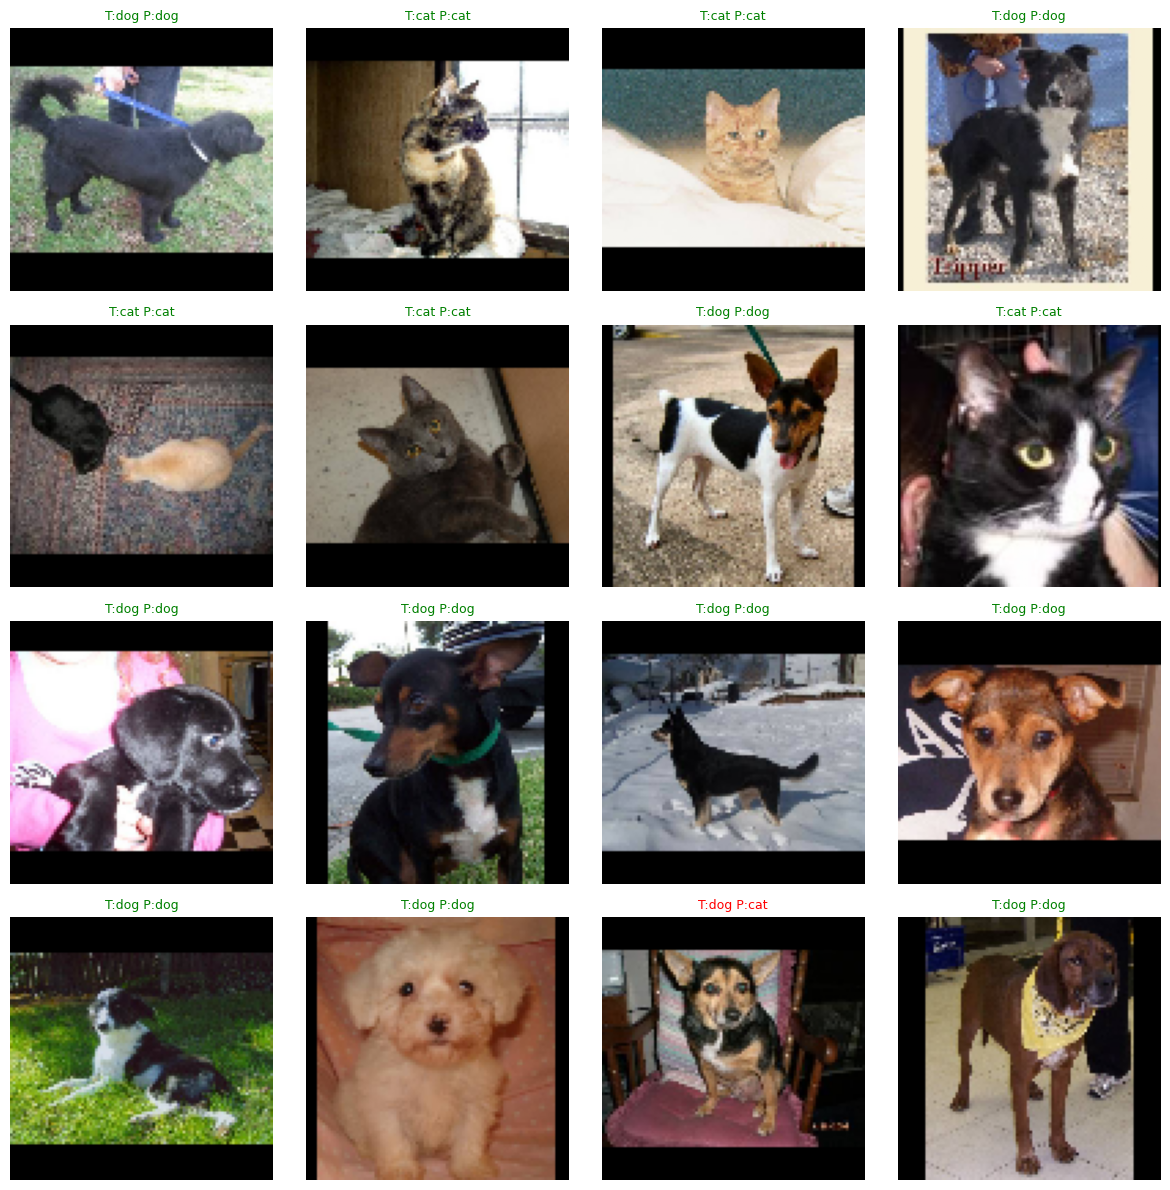

In [11]:
# Show sample predictions from the internal test split
plot_sample_predictions(
    images=X_test,
    y_true=y_test,
    y_pred=best_y_pred,
    n=16,
)

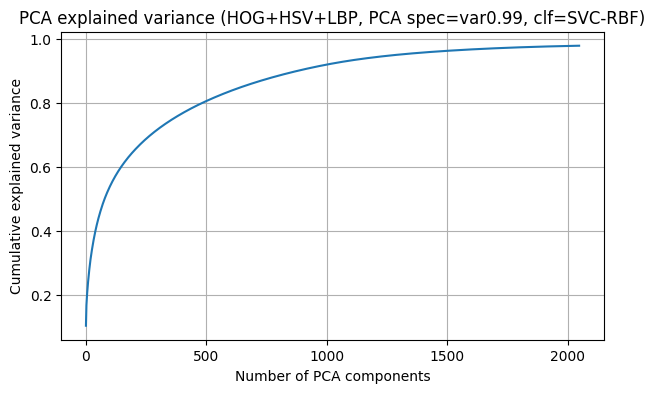

Cumulative variance with 2048 components: 0.979


In [12]:
# Plot cumulative explained variance for the selected PCA model
cumulative_ev = np.cumsum(best_pca.explained_variance_ratio_)

plt.figure(figsize=(7, 4))
plt.plot(range(1, len(cumulative_ev) + 1), cumulative_ev)
plt.xlabel("Number of PCA components")
plt.ylabel("Cumulative explained variance")
_pca_t = format_pca_spec_label(best_pca_spec)
plt.title(
    "PCA explained variance (HOG+HSV+LBP, PCA spec={}, clf={})".format(
        _pca_t,
        best_clf_label,
    )
)
plt.grid(True)
plt.show()

n_kept = len(cumulative_ev)
print(
    "Cumulative variance with {} components: {:.3f}".format(
        n_kept,
        float(cumulative_ev[-1]),
    )
)


In [13]:
# ---------------------------------------------------------------------------
# Retrain best PCA + classifier on ALL labeled data; Kaggle submission with optional hflip TTA
# ---------------------------------------------------------------------------

USE_TEST_TIME_FLIP = True

print("Extracting features for full training set...")
X_all_feats = extract_combined_features(
    X,
    hog_orientations=HOG_ORIENTATIONS,
    hog_cells_per_block=HOG_CELLS_PER_BLOCK,
    hog_scales_ppc=HOG_SCALES_PPC,
    hsv_bins=HSV_BINS,
    n_jobs=FEAT_EXTRACT_N_JOBS,
    include_lbp=INCLUDE_LBP,
    lbp_n_points=LBP_N_POINTS,
    lbp_radius=LBP_RADIUS,
)

X_all_s, _, scaler_final = standardize_features(X_all_feats, X_all_feats)

X_all_pca, pca_final = fit_pca_train_only_auto(X_all_s, best_pca_spec)

clf_final = clone(best_clf)
clf_final.fit(X_all_pca, y)
print("Final model trained on all labeled data.")

print("Loading Kaggle test images...")
X_kaggle_test, kaggle_ids = load_test_images(
    img_size=IMG_SIZE_OPT_B,
    grayscale=False,
    letterbox=LETTERBOX,
)

print("Extracting features for Kaggle test set...")
X_kaggle_feats = extract_combined_features(
    X_kaggle_test,
    hog_orientations=HOG_ORIENTATIONS,
    hog_cells_per_block=HOG_CELLS_PER_BLOCK,
    hog_scales_ppc=HOG_SCALES_PPC,
    hsv_bins=HSV_BINS,
    n_jobs=FEAT_EXTRACT_N_JOBS,
    include_lbp=INCLUDE_LBP,
    lbp_n_points=LBP_N_POINTS,
    lbp_radius=LBP_RADIUS,
)

X_kaggle_s = scaler_final.transform(X_kaggle_feats)
X_kaggle_pca = pca_final.transform(X_kaggle_s)


def _dog_proba_from_clf(clf, Xp):
    if hasattr(clf, "predict_proba"):
        return clf.predict_proba(Xp)[:, 1]
    from scipy.special import expit

    return expit(clf.decision_function(Xp))


kaggle_pred_proba = _dog_proba_from_clf(clf_final, X_kaggle_pca)

if USE_TEST_TIME_FLIP:
    X_kaggle_flip = np.flip(X_kaggle_test, axis=2)
    X_kaggle_feats_f = extract_combined_features(
        X_kaggle_flip,
        hog_orientations=HOG_ORIENTATIONS,
        hog_cells_per_block=HOG_CELLS_PER_BLOCK,
        hog_scales_ppc=HOG_SCALES_PPC,
        hsv_bins=HSV_BINS,
        n_jobs=FEAT_EXTRACT_N_JOBS,
        include_lbp=INCLUDE_LBP,
        lbp_n_points=LBP_N_POINTS,
        lbp_radius=LBP_RADIUS,
    )
    X_kaggle_s_f = scaler_final.transform(X_kaggle_feats_f)
    X_kaggle_pca_f = pca_final.transform(X_kaggle_s_f)
    p_f = _dog_proba_from_clf(clf_final, X_kaggle_pca_f)
    kaggle_pred_proba = (kaggle_pred_proba + p_f) / 2.0

kaggle_pred = (kaggle_pred_proba >= 0.5).astype(np.int64)

submission_path = (
    OUTPUTS_DIR / "submissions" / "optionB_multihog_hsv_pca_rf_submission.csv"
)
submission_path = generate_submission_csv(kaggle_ids, kaggle_pred, submission_path)

debug_path = (
    OUTPUTS_DIR / "tests" / "optionB_multihog_hsv_pca_rf_submission_proba.csv"
)
debug_path = generate_submission_csv(kaggle_ids, kaggle_pred_proba, debug_path)

print("Submission saved to: {}".format(submission_path))
print("Debug (P(dog)) saved to: {}".format(debug_path))


Extracting features for full training set...
Final model trained on all labeled data.
Loading Kaggle test images...


Loading test images: 100%|██████████| 5000/5000 [00:01<00:00, 2698.49it/s]


Extracting features for Kaggle test set...
Submission saved to: C:\Users\cotte\Documents\Program\github\ecse415-final-project\outputs\submissions\optionB_multihog_hsv_pca_rf_submission.csv
Debug (P(dog)) saved to: C:\Users\cotte\Documents\Program\github\ecse415-final-project\outputs\tests\optionB_multihog_hsv_pca_rf_submission_proba.csv


### Notes for report (Part 1 Option B)

- **Pipeline**: RGB images letterboxed to `IMG_SIZE_OPT_B` (scale to fit, black padding, no stretch) → triple-scale HOG
  (ppc=8, 12, 16; 9 orientations; cpb=2×2) + HSV histogram (16 bins × 3) + LBP histogram → StandardScaler → PCA
  (fixed `n` or retained variance; PyTorch on GPU when available) → SVC (RBF); optional hflip TTA on the test set.
- **Why multi-scale HOG?** Fine (ppc=8) vs mid (ppc=12) vs coarse (ppc=16) cells capture texture through silhouette cues.
- **Why HSV?** Cats and dogs exhibit distinct fur-color distributions; HSV separates hue from
  luminance, making the histogram more robust to lighting changes.
- Report the best PCA spec (`n` or retained variance), classifier name, internal accuracy, precision, recall, and F1.
- Include the confusion matrix figure from the internal test split.
- Compare this Option B result against Option A and Option C models.
- Briefly discuss failure patterns seen in the sample prediction grid.
